In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!git clone https://github.com/dengxiaozhi/SACC.git

Cloning into 'SACC'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 42 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 1.17 MiB | 8.77 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [2]:
# Move into the repo
%cd SACC

/kaggle/working/SACC


In [3]:
!ls


cluster.py  evaluation	LICENSE  README.md  train_STL10.py
config	    figures	modules  train.py   utils


In [5]:
# Required imports / dependencies for EDA

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

100%|██████████| 2.64G/2.64G [03:14<00:00, 13.6MB/s] 


TRAIN SIZE: 5000
TEST SIZE: 8000
NUMBER OF CLASSES: 10
IMAGE SIZE: (96, 96)


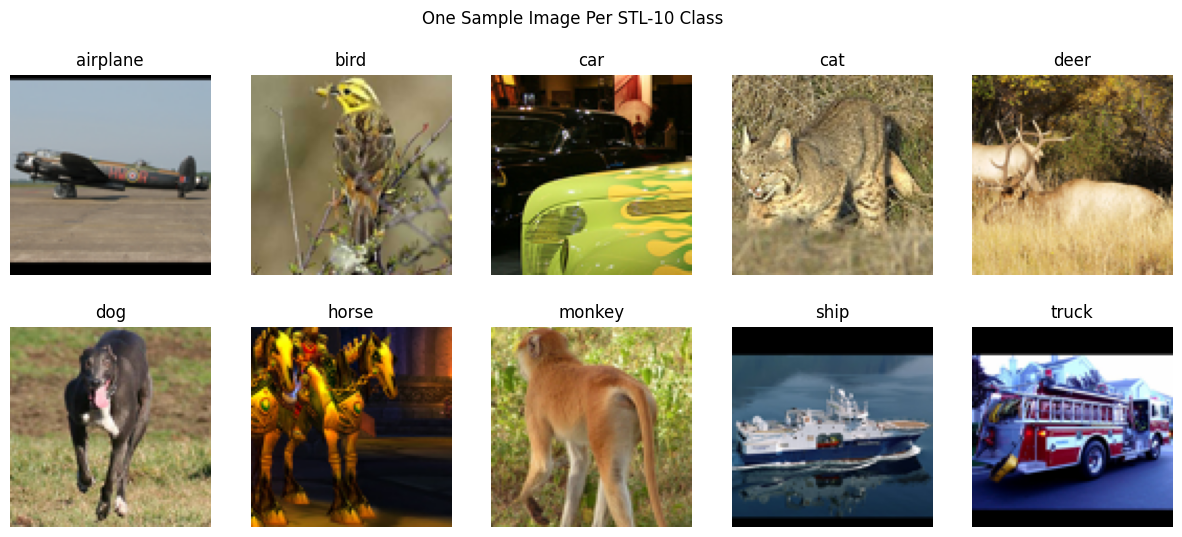

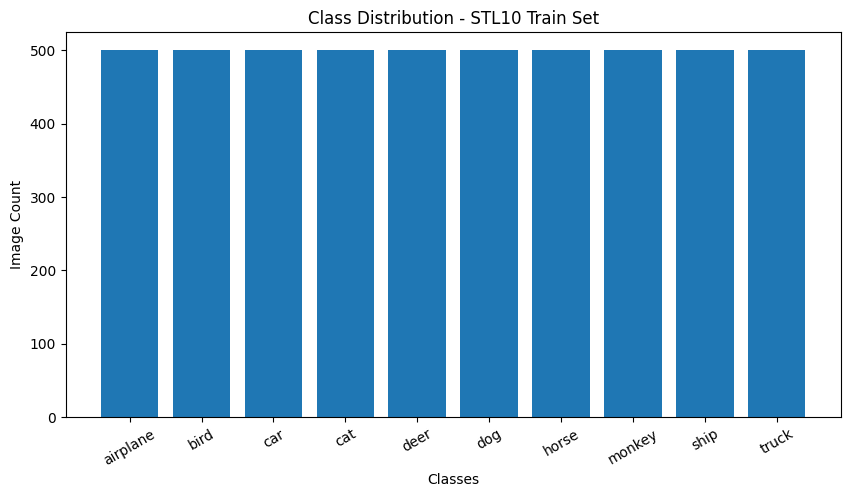

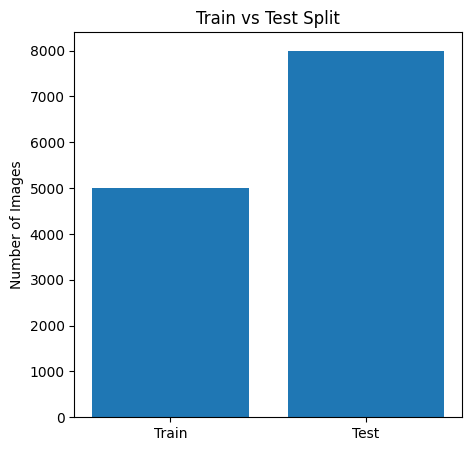

In [6]:
# QUICK EDA FOR STL-10

import torchvision
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# STL-10 class names
classes = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# Load datasets
train_dataset = torchvision.datasets.STL10(
    root="/kaggle/working/datasets",
    split="train",
    download=True
)

test_dataset = torchvision.datasets.STL10(
    root="/kaggle/working/datasets",
    split="test",
    download=True
)

# ---------------------------------------------------
# BASIC SUMMARY
# ---------------------------------------------------

print("TRAIN SIZE:", len(train_dataset))
print("TEST SIZE:", len(test_dataset))
print("NUMBER OF CLASSES:", len(classes))

sample_img, sample_label = train_dataset[0]
print("IMAGE SIZE:", sample_img.size)

# ---------------------------------------------------
# ONE SAMPLE IMAGE PER CLASS
# ---------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(15,6))

shown = set()

for img, label in train_dataset:
    if label not in shown:
        ax = axes[label // 5][label % 5]
        ax.imshow(img)
        ax.set_title(classes[label])
        ax.axis("off")
        shown.add(label)

    if len(shown) == 10:
        break

plt.suptitle("One Sample Image Per STL-10 Class")
plt.show()

# ---------------------------------------------------
# CLASS DISTRIBUTION
# ---------------------------------------------------

train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)

plt.figure(figsize=(10,5))
plt.bar(classes, [label_counts[i] for i in range(10)])
plt.title("Class Distribution - STL10 Train Set")
plt.xlabel("Classes")
plt.ylabel("Image Count")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------
# TRAIN VS TEST SPLIT
# ---------------------------------------------------

train_count = len(train_dataset)
test_count = len(test_dataset)

plt.figure(figsize=(5,5))
plt.bar(["Train", "Test"], [train_count, test_count])
plt.title("Train vs Test Split")
plt.ylabel("Number of Images")
plt.show()

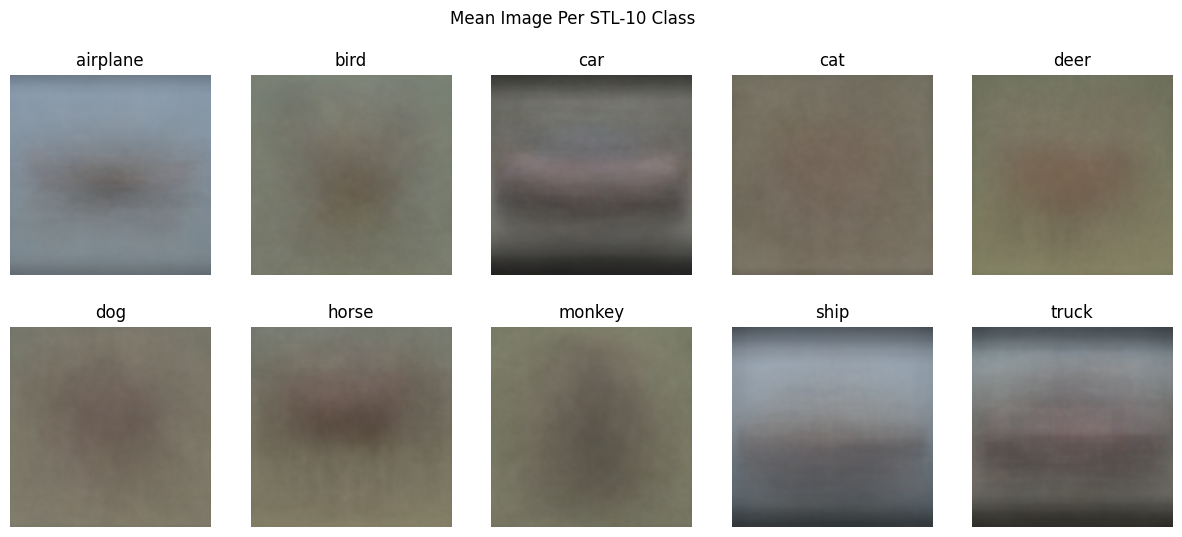

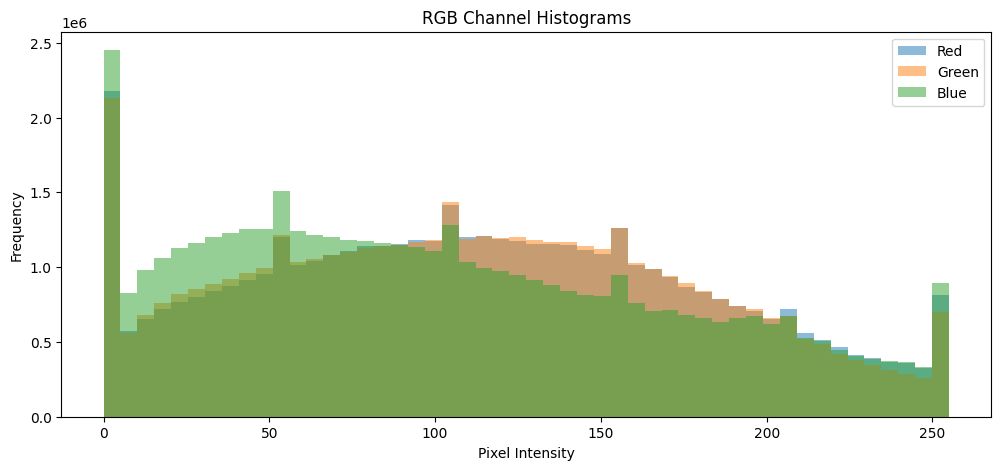

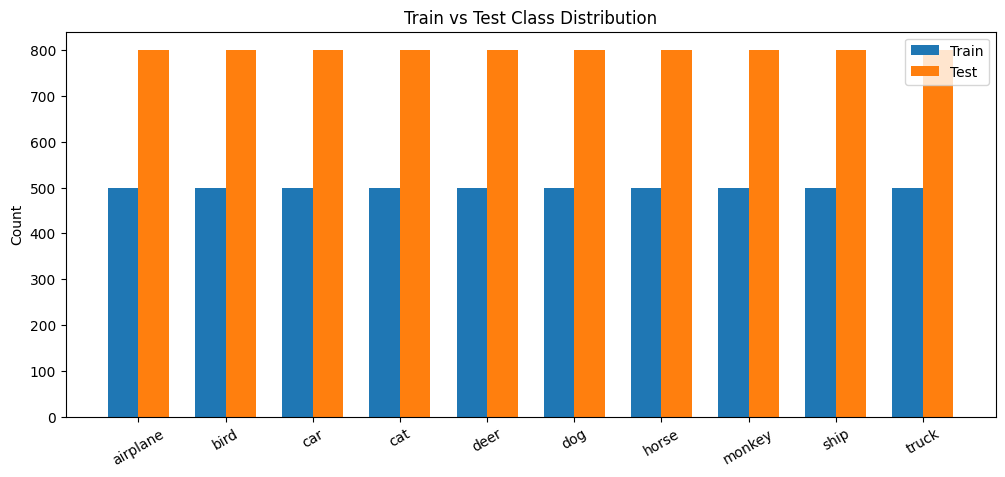

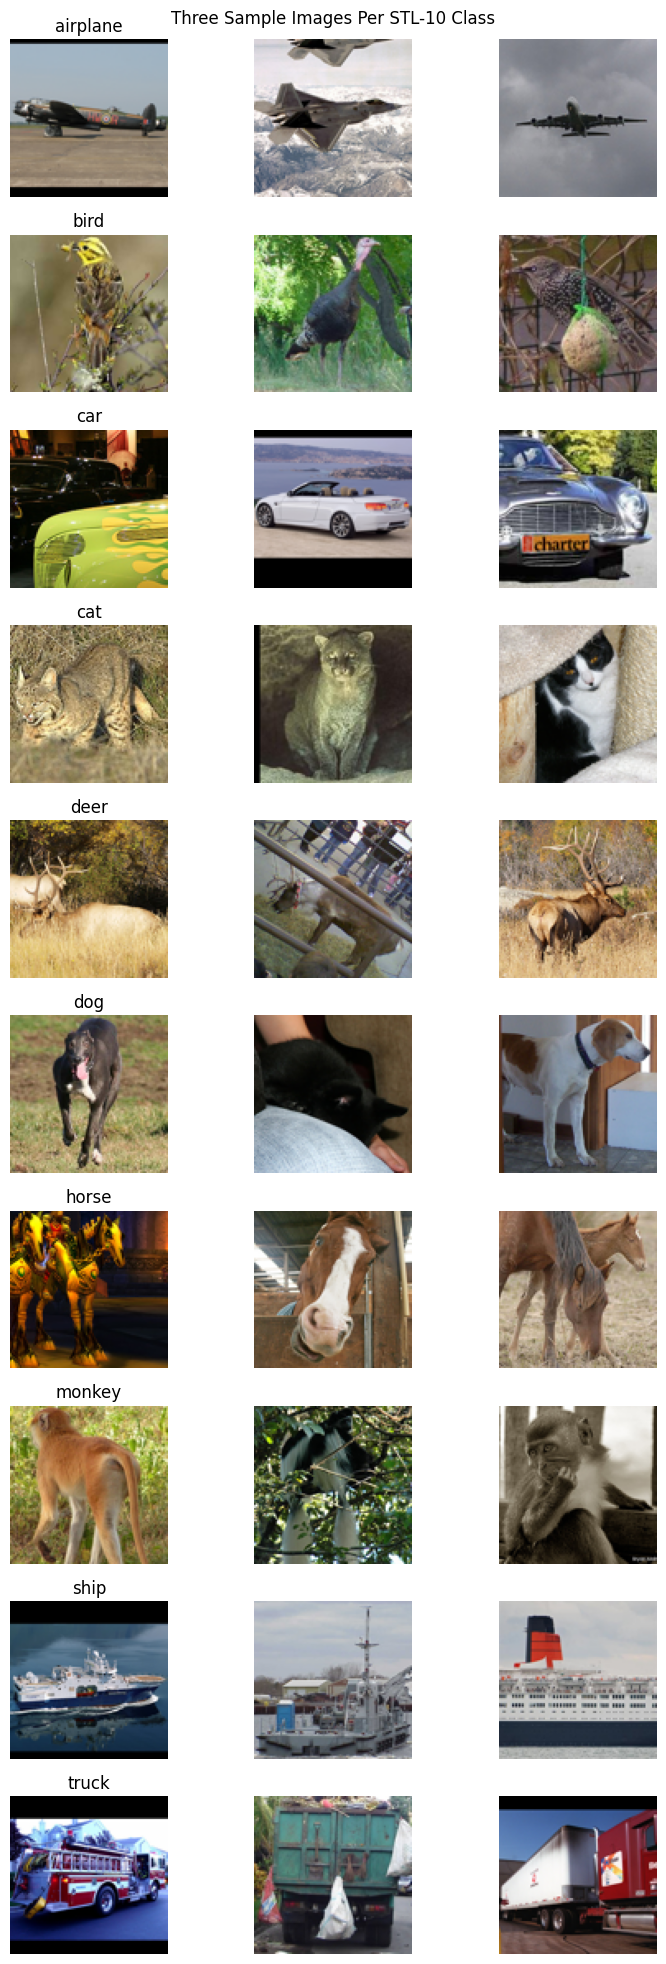

In [7]:
# FULL EDA FOR STL-10

import torchvision
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

classes = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# Load datasets
train_dataset = torchvision.datasets.STL10(
    root="/kaggle/working/datasets",
    split="train",
    download=False
)

test_dataset = torchvision.datasets.STL10(
    root="/kaggle/working/datasets",
    split="test",
    download=False
)

# =========================================================
# 1. MEAN IMAGE PER CLASS
# =========================================================

fig, axes = plt.subplots(2, 5, figsize=(15,6))

for class_id in range(10):

    images = []

    for img, label in train_dataset:
        if label == class_id:
            images.append(np.array(img)/255.0)

    mean_img = np.mean(images, axis=0)

    ax = axes[class_id // 5][class_id % 5]
    ax.imshow(mean_img)
    ax.set_title(classes[class_id])
    ax.axis("off")

plt.suptitle("Mean Image Per STL-10 Class")
plt.show()

# =========================================================
# 2. RGB CHANNEL HISTOGRAMS
# =========================================================

all_pixels = []

for img, _ in train_dataset:
    arr = np.array(img)
    all_pixels.append(arr.reshape(-1, 3))

all_pixels = np.concatenate(all_pixels, axis=0)

plt.figure(figsize=(12,5))

colors = ["Red", "Green", "Blue"]

for i in range(3):
    plt.hist(
        all_pixels[:, i],
        bins=50,
        alpha=0.5,
        label=colors[i]
    )

plt.title("RGB Channel Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# =========================================================
# 3. TRAIN VS TEST CLASS BALANCE
# =========================================================

train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12,5))

plt.bar(x - width/2,
        [train_counts[i] for i in range(10)],
        width,
        label="Train")

plt.bar(x + width/2,
        [test_counts[i] for i in range(10)],
        width,
        label="Test")

plt.xticks(x, classes, rotation=30)
plt.ylabel("Count")
plt.title("Train vs Test Class Distribution")
plt.legend()
plt.show()

# =========================================================
# 4. SAMPLE GRID (3 IMAGES PER CLASS)
# =========================================================

fig, axes = plt.subplots(10, 3, figsize=(8,20))

for class_id in range(10):

    count = 0

    for img, label in train_dataset:

        if label == class_id:

            axes[class_id][count].imshow(img)
            axes[class_id][count].axis("off")

            if count == 0:
                axes[class_id][count].set_title(classes[class_id])

            count += 1

            if count == 3:
                break

plt.suptitle("Three Sample Images Per STL-10 Class")
plt.tight_layout()
plt.show()

In [5]:
%cd /kaggle/working

!git clone https://github.com/dengxiaozhi/SACC.git

%cd SACC

!ls

/kaggle/working
Cloning into 'SACC'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 42 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 1.17 MiB | 7.11 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/kaggle/working/SACC
cluster.py  evaluation	LICENSE  README.md  train_STL10.py
config	    figures	modules  train.py   utils


In [6]:
!pip install -q munkres pyyaml scikit-learn opencv-python


In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
# Patch train_STL10.py 

path = "/kaggle/working/SACC/train_STL10.py"

with open(path, "r") as f:
    code = f.read()

code = code.replace("from cluster_training import test_load, test", "# skipped cluster_training import")
code = code.replace("    test_data_loader = test_load(args)", "    # skipped test_data_loader during training")
code = code.replace(
"""        if epoch % 10 == 0:
            test(args, test_data_loader, epoch, loss_device, model)""",
"""        # skipped intermediate clustering evaluation during training"""
)

with open(path, "w") as f:
    f.write(code)

print("Patched train_STL10.py successfully.")

Patched train_STL10.py successfully.


In [ ]:
!python train_STL10.py \
  --dataset STL-10 \
  --dataset_dir /kaggle/working/datasets \
  --epochs 100 \
  --batch_size 128 \
  --workers 4 \
  --image_size 64 \
  --model_path save/STL-10

Step [0/781]	 loss_instance: 11.069125175476074
Step [50/781]	 loss_instance: 10.9370698928833
Step [100/781]	 loss_instance: 10.644438743591309
Step [150/781]	 loss_instance: 10.398414611816406
Step [200/781]	 loss_instance: 10.255492210388184
Step [250/781]	 loss_instance: 10.291446685791016
Step [300/781]	 loss_instance: 9.860418319702148
Step [350/781]	 loss_instance: 9.842817306518555
Step [400/781]	 loss_instance: 9.958751678466797
Step [450/781]	 loss_instance: 9.737092018127441
Step [500/781]	 loss_instance: 9.601183891296387
Step [550/781]	 loss_instance: 9.620345115661621
Step [600/781]	 loss_instance: 9.639705657958984
Step [650/781]	 loss_instance: 9.42391300201416
Step [700/781]	 loss_instance: 9.583883285522461
Step [750/781]	 loss_instance: 9.422082901000977
Step [0/101]	 loss_instance: 9.549962997436523	 loss_cluster: 5.9482526779174805
Step [50/101]	 loss_instance: 9.395785331726074	 loss_cluster: 5.034958839416504
Step [100/101]	 loss_instance: 9.337696075439453	 loss

In [8]:
!python cluster.py \
  --dataset STL-10 \
  --dataset_dir /kaggle/working/datasets \
  --start_epoch 100 \
  --workers 4 \
  --image_size 64 \
  --model_path /kaggle/input/notebooks/alizamazher25/dm-project-stl/SACC/save/STL-10

100%|██████████████████████████████████████| 2.64G/2.64G [02:09<00:00, 20.3MB/s]
### Creating features from model ###
Step [0/7]	 Computing features...
Features shape (13000,)
NMI = 0.5133 ARI = 0.3829 F = 0.4454 ACC = 0.5701


In [10]:
!find /kaggle/input -name "*.txt"

/kaggle/input/datasets/alizamazher25/logs-stl/logs.txt
/kaggle/input/notebooks/alizamazher25/dm-project-stl/datasets/stl10_binary/class_names.txt
/kaggle/input/notebooks/alizamazher25/dm-project-stl/datasets/stl10_binary/fold_indices.txt


Epochs found: 100
Initial loss: 11.760245777428073
Final loss: 9.780695621549091
Total loss drop: 1.9795501558789823


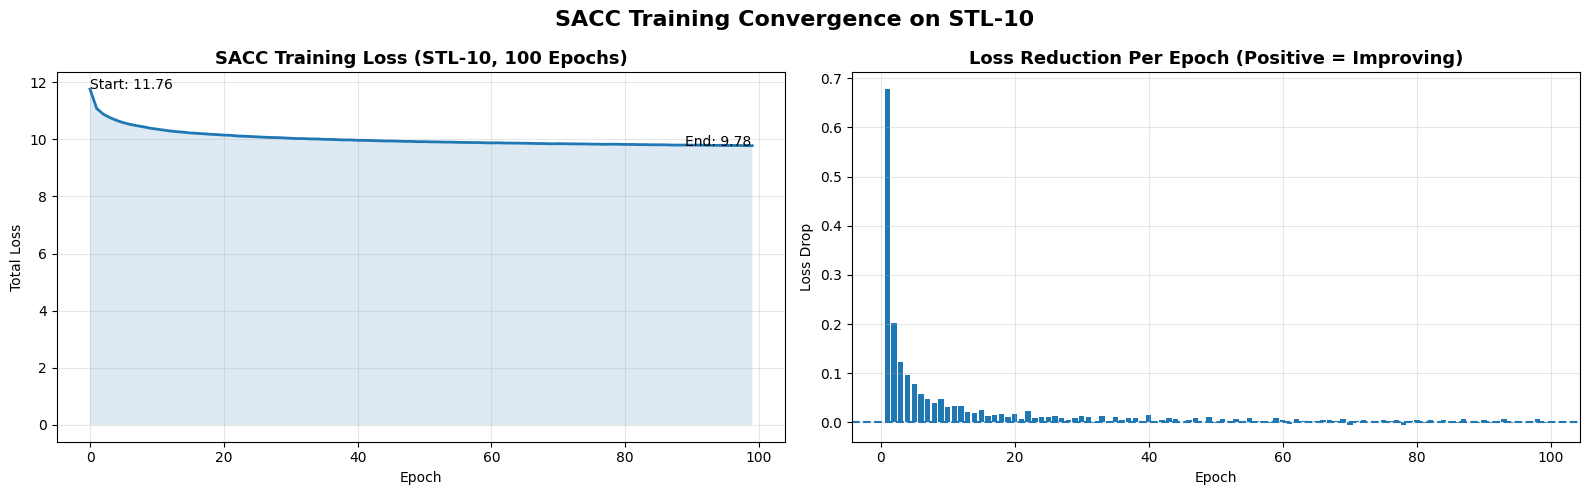


Graph saved successfully.
PNG file: /kaggle/working/stl10_training_convergence.png
CSV file: /kaggle/working/stl10_epoch_losses.csv


In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read uploaded STL-10 training logs
with open('/kaggle/input/datasets/alizamazher25/logs-stl/logs.txt', 'r', encoding='utf-8') as f:
    log_text = f.read()

# Extract epoch losses
matches = re.findall(r"Epoch\s*\[(\d+)/100\]\s*Loss:\s*([0-9.]+)", log_text)

epochs = [int(e) for e, l in matches]
losses = [float(l) for e, l in matches]

print("Epochs found:", len(epochs))
print("Initial loss:", losses[0])
print("Final loss:", losses[-1])
print("Total loss drop:", losses[0] - losses[-1])

# Compute loss improvement per epoch
loss_drop = np.diff(losses) * -1

# Save losses as CSV
df = pd.DataFrame({
    "Epoch": epochs,
    "Loss": losses
})

df.to_csv("/kaggle/working/stl10_epoch_losses.csv", index=False)

# Create graphs
plt.figure(figsize=(16,5))

# ---------------- LEFT GRAPH ----------------
plt.subplot(1,2,1)

plt.plot(epochs, losses, linewidth=2)
plt.fill_between(epochs, losses, alpha=0.15)

plt.title("SACC Training Loss (STL-10, 100 Epochs)",
          fontsize=13,
          fontweight='bold')

plt.xlabel("Epoch")
plt.ylabel("Total Loss")

plt.grid(True, alpha=0.3)

plt.text(epochs[0], losses[0],
         f"Start: {losses[0]:.2f}")

plt.text(epochs[-1]-10, losses[-1],
         f"End: {losses[-1]:.2f}")

# ---------------- RIGHT GRAPH ----------------
plt.subplot(1,2,2)

plt.bar(epochs[1:], loss_drop)

plt.axhline(0, linestyle='--')

plt.title("Loss Reduction Per Epoch (Positive = Improving)",
          fontsize=13,
          fontweight='bold')

plt.xlabel("Epoch")
plt.ylabel("Loss Drop")

plt.grid(True, alpha=0.3)

# ---------------- MAIN TITLE ----------------
plt.suptitle("SACC Training Convergence on STL-10",
             fontsize=16,
             fontweight='bold')

plt.tight_layout()

# Save graph
plt.savefig("/kaggle/working/stl10_training_convergence.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

print("\nGraph saved successfully.")
print("PNG file: /kaggle/working/stl10_training_convergence.png")
print("CSV file: /kaggle/working/stl10_epoch_losses.csv")

# Comparison with Original SACC Paper

The original SACC paper reported significantly higher clustering performance on the STL-10 dataset than the results obtained in our implementation. Specifically, the paper achieved **NMI = 69.1%**, **ACC = 75.9%**, and **ARI = 62.6%** on STL-10 after training for **1000 epochs** using the full proposed configuration. 

In contrast, our implementation achieved:

* **NMI = 0.5133 (51.33%)**
* **ACC = 0.5701 (57.01%)**
* **ARI = 0.3829 (38.29%)**
* **F-score = 0.4454 (44.54%)**

after training for only **100 epochs**.

The difference in performance is expected due to several modifications and computational constraints in our experiment setup:

| Aspect        | Original Paper                 | Our Experiment          |
| ------------- | ------------------------------ | ----------------------- |
| Epochs        | 1000                           | 100                     |
| Image Size    | 224 × 224                      | 64 × 64                 |
| Batch Size    | 200                            | 128                     |
| Backbone      | ResNet-34                      | Same                    |
| Dataset       | STL-10                         | STL-10                  |
| Training Time | Much longer                    | Reduced for feasibility |
| GPU Resources | Research-grade multi-GPU setup | Kaggle T4 GPUs          |

The paper explicitly states that SACC performance continues improving as epochs increase and that stable high-quality clustering is typically achieved after **500+ epochs**.  Therefore, our lower scores are primarily due to the reduced training duration.

Additionally, we used a smaller image size (**64×64 instead of 224×224**) to reduce GPU memory usage and training time (these 100 epochs took around 12 hours too). This reduces the amount of visual information available to the network and can negatively affect feature representation quality. The reduced batch size and Kaggle hardware limitations may also contribute to weaker convergence.

Despite these limitations, our implementation successfully reproduced the SACC training pipeline and achieved meaningful unsupervised clustering performance on STL-10. The obtained results still demonstrate the effectiveness of contrastive clustering using strong and weak augmentations, consistent with the behavior described in the original paper. 
